In [2]:
from pathlib import Path

import lightgbm as lgb
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split

print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.7.0


In [3]:
base_path = Path("../..")
data_path = base_path / "data" / "raw"

train_df = pd.read_csv(data_path / "train.csv")
test_df = pd.read_csv(data_path / "test.csv")
sample_submission = pd.read_csv(data_path / "sample_submission.csv")

print(f"train shape: {train_df.shape}")
print(f"test shape:  {test_df.shape}")
print(f"sample submission shape: {sample_submission.shape}")

train shape: (668665, 15)
test shape:  (286571, 14)
sample submission shape: (286571, 2)


In [4]:
display(train_df.head())
display(train_df.dtypes.rename("dtype").to_frame())

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


,dtype
id,int64
Age,int64
Annual_Income_USD,float64
Daily_Commute_km,float64
Number_of_Cars_Owned,int64
Charging_Stations_Near_Home,int64
Charging_Stations_Near_Work,int64
Environmental_Concern_Level,float64
Gender,str
City_Type,str


In [5]:
print("Missing values in train:", train_df.isna().sum().sum())
print("Missing values in test:", test_df.isna().sum().sum())
print("Duplicate train rows:", train_df.duplicated().sum())

display(
    train_df["Will_Buy_EV"]
    .value_counts(dropna=False)
    .to_frame("count")
    .assign(share=lambda frame: frame["count"] / len(train_df))
)

Missing values in train: 0
Missing values in test: 0
Duplicate train rows: 0


,count,share
Will_Buy_EV,,
No,551886,0.825355
Yes,116779,0.174645


In [6]:
target_column = "Will_Buy_EV"

train_ids = train_df["id"].copy()
test_ids = test_df["id"].copy()

X = train_df.drop(columns=["id", target_column]).copy()
y = train_df[target_column].map({"No": 0, "Yes": 1}).astype("int8")
X_test = test_df.drop(columns="id").copy()

assert y.notna().all(), "Target contains unexpected values"
assert X.columns.equals(X_test.columns), "Train and test features do not match"

In [7]:
categorical_features = X.select_dtypes(exclude="number").columns.tolist()
numerical_features = X.select_dtypes(include="number").columns.tolist()

for column in categorical_features:
    X[column] = X[column].astype("category")
    X_test[column] = pd.Categorical(
        X_test[column],
        categories=X[column].cat.categories,
    )

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)
print("Unexpected test categories:", X_test[categorical_features].isna().sum().sum())

Categorical features: ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']
Numerical features: ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level']
Unexpected test categories: 0


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [9]:
model = LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
)

In [10]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100),
    ],
)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.940358	valid_0's binary_logloss: 0.229381
[200]	valid_0's auc: 0.941136	valid_0's binary_logloss: 0.22772
[300]	valid_0's auc: 0.941308	valid_0's binary_logloss: 0.227405
[400]	valid_0's auc: 0.941375	valid_0's binary_logloss: 0.227284
[500]	valid_0's auc: 0.941456	valid_0's binary_logloss: 0.227143
[600]	valid_0's auc: 0.941463	valid_0's binary_logloss: 0.227135
Early stopping, best iteration is:
[540]	valid_0's auc: 0.941479	valid_0's binary_logloss: 0.227105


,learning_rate,0.05
,n_estimators,1000
,objective,'binary'
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [11]:
val_probability = model.predict_proba(
    X_val,
    num_iteration=model.best_iteration_,
)[:, 1]

In [12]:
from sklearn.metrics import f1_score
val_prediction = (val_probability >= 0.5).astype(int)

auc = roc_auc_score(y_val, val_probability)
f1 = f1_score(y_val, val_prediction)

print(f"ROC-AUC: {auc:.6f}")
print(f"F1 at threshold 0.5: {f1:.6f}")

ROC-AUC: 0.941479
F1 at threshold 0.5: 0.697798


In [13]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_val, val_prediction)
recall = recall_score(y_val, val_prediction)

print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")

Precision: 0.722941
Recall: 0.674345


In [14]:
thresholds = np.arange(0.05, 0.96, 0.01)

f1_scores = [
    f1_score(
        y_val,
        (val_probability >= threshold).astype(int),
    )
    for threshold in thresholds
]

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1: {best_f1:.6f}")

Best threshold: 0.35
Best F1: 0.715328


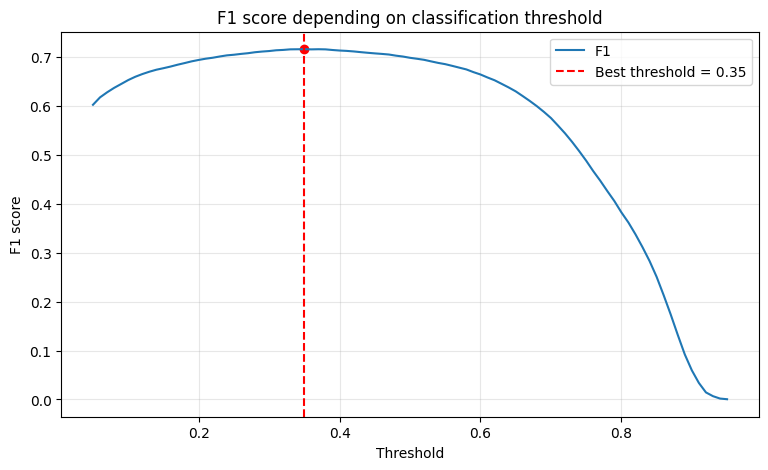

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(thresholds, f1_scores, label="F1")
plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}",
)
plt.scatter(best_threshold, best_f1, color="red")

plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("F1 score depending on classification threshold")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [ ]:
oof_probability = np.zeros(len(X))
fold_auc_scores = []

for fold, (train_index, valid_index) in enumerate(
    cv.split(X, y),
    start=1,
):
    X_train_fold = X.iloc[train_index]
    X_valid_fold = X.iloc[valid_index]

    y_train_fold = y.iloc[train_index]
    y_valid_fold = y.iloc[valid_index]

    print(
        f"Fold {fold}:",
        X_train_fold.shape,
        X_valid_fold.shape,
    )

    fold_model = LGBMClassifier(
        objective="binary",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
    )

    fold_model.fit(
        X_train_fold,
        y_train_fold,
        eval_X=X_valid_fold,
        eval_y=y_valid_fold,
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100),
        ],
    )

    fold_probability = fold_model.predict_proba(
        X_valid_fold,
        num_iteration=fold_model.best_iteration_,
    )[:, 1]

    oof_probability[valid_index] = fold_probability

    fold_auc = roc_auc_score(
        y_valid_fold,
        fold_probability,
    )
    fold_auc_scores.append(fold_auc)

    print(f"Fold {fold} ROC-AUC: {fold_auc:.6f}")

Fold 1: (534932, 13) (133733, 13)
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.93908	valid_0's binary_logloss: 0.231474
[200]	valid_0's auc: 0.939989	valid_0's binary_logloss: 0.229702
[300]	valid_0's auc: 0.940217	valid_0's binary_logloss: 0.229313
[400]	valid_0's auc: 0.940278	valid_0's binary_logloss: 0.229208
[500]	valid_0's auc: 0.940306	valid_0's binary_logloss: 0.22917
[600]	valid_0's auc: 0.940381	valid_0's binary_logloss: 0.229044
Early stopping, best iteration is:
[592]	valid_0's auc: 0.940382	valid_0's binary_logloss: 0.229041
Fold 1 ROC-AUC: 0.940382
Fold 2: (534932, 13) (133733, 13)
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.940355	valid_0's binary_logloss: 0.22947
[200]	valid_0's auc: 0.941138	valid_0's binary_logloss: 0.227777
[300]	valid_0's auc: 0.941245	valid_0's binary_logloss: 0.227559
[400]	valid_0's auc: 0.94134	valid_0's binary_logloss: 0.227396
[500]	valid_0's auc: 0.941337	valid_0

In [24]:
fold_auc_scores = fold_auc_scores[-5:]
mean_fold_auc = np.mean(fold_auc_scores)
std_fold_auc = np.std(fold_auc_scores)
oof_auc = roc_auc_score(y, oof_probability)

print(f"Fold AUC scores: {fold_auc_scores}")
print(f"Mean fold AUC: {mean_fold_auc:.6f}")
print(f"Fold AUC std: {std_fold_auc:.6f}")
print(f"OOF ROC-AUC: {oof_auc:.6f}")

Fold AUC scores: [0.9403824712912443, 0.9413660947415453, 0.9427495181808527, 0.9421866244330064, 0.9416454408307198]
Mean fold AUC: 0.941666
Fold AUC std: 0.000798
OOF ROC-AUC: 0.941655


Fold 5 ROC-AUC: 0.941645
